<a href="https://colab.research.google.com/github/dbansal02/SciML_ME697_Project/blob/main/PIFT_Example1_and_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIFT Example 5.1 in JAX
## 1D steady-state heat equation

This notebook implements a simple JAX version of Example 1 from the paper:
Alex Alberts, Ilias Bilionis; Physics-informed information field theory for modeling physical systems with uncertainty quantification.

The goal is to understand how the physics-informed prior behaves as the inverse-temperature
parameter $\beta$ changes.

We study the 1D boundary value problem

$$
D \frac{d^2 \phi}{dx^2} + q(x) = 0, \qquad x \in [0,1],
$$

with boundary conditions

$$
\phi(0)=1, \qquad \phi(1)=0.1.
$$

For this example, we use

$$
D = 0.25, \qquad q(x)=e^{-x}.
$$

Instead of solving the PDE directly, we parameterize the field $\phi(x)$ using a finite set
of coefficients and then define a physics-informed energy functional.

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Enable float64 for better numerical stability
jax.config.update("jax_enable_x64", True)

# Problem constants
D = 0.25
phi_left = 1.0
phi_right = 0.1

# Number of Fourier modes
K = 20

# Grid for plotting / deterministic integration
x_plot = jnp.linspace(0.0, 1.0, 400)

def q_source(x):
    return jnp.exp(-x)

## Field parameterization

To automatically satisfy the boundary conditions, we write the field as
$$
\hat{\phi}(x;\theta) = (1-x)\phi(0) + x\phi(1) + (1-x)x\,\psi(x;\theta),$$
where $\psi(x;\theta)$ is a truncated Fourier series.

This construction is useful because the factor $(1-x)x$ vanishes at both boundaries,
so no matter what coefficients are used in $\psi$, the boundary conditions remain satisfied.

In [ ]:
def psi(x, theta):
    """
    Truncated Fourier series:
        psi(x) = a0 + sum_{j=1}^K [a_j cos(2 pi j x) + b_j sin(2 pi j x)]

    theta has length 1 + 2K:
        theta = [a0, a1, ..., aK, b1, ..., bK]
    """
    a0 = theta[0]
    a_cos = theta[1:K+1]
    b_sin = theta[K+1:2*K+1]

    j = jnp.arange(1, K + 1)
    x = jnp.atleast_1d(x)

    cos_terms = jnp.cos(2.0 * jnp.pi * j[None, :] * x[:, None])
    sin_terms = jnp.sin(2.0 * jnp.pi * j[None, :] * x[:, None])

    val = (
        a0
        + jnp.sum(a_cos[None, :] * cos_terms, axis=1)
        + jnp.sum(b_sin[None, :] * sin_terms, axis=1)
    )
    return val


def phi_hat(x, theta):
    """
    Boundary-condition-satisfying field parameterization.
    """
    x = jnp.atleast_1d(x)
    base = (1.0 - x) * phi_left + x * phi_right
    return base + (1.0 - x) * x * psi(x, theta)

## Sanity check: boundary conditions

Before doing anything else, we should verify that the parameterization satisfies
$$
\hat{\phi}(0;\theta)=1, \qquad \hat{\phi}(1;\theta)=0.1 $$

for any coefficient vector $\theta$.

In [ ]:
key = jax.random.PRNGKey(0)
theta_test = jax.random.normal(key, shape=(1 + 2*K,))

print("theta length:", theta_test.shape[0])
print("phi(0) =", float(phi_hat(jnp.array([0.0]), theta_test)[0]))
print("phi(1) =", float(phi_hat(jnp.array([1.0]), theta_test)[0]))

theta length: 41
phi(0) = 1.0
phi(1) = 0.1


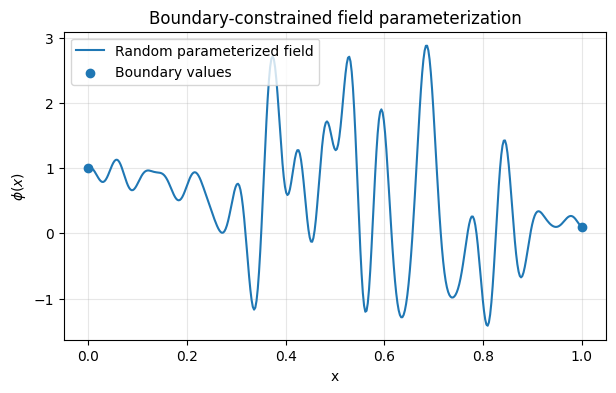

In [ ]:
phi_test = phi_hat(x_plot, theta_test)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, phi_test, label="Random parameterized field")
plt.scatter([0.0, 1.0], [phi_left, phi_right], zorder=3, label="Boundary values")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Boundary-constrained field parameterization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Energy functional

Instead of solving the PDE directly, we define an energy functional whose minimizer
corresponds to the solution of the differential equation.

For the steady-state heat equation, the energy is

$$
U[\phi] = \int_0^1 \left[ \frac{1}{2} D \left(\frac{d\phi}{dx}\right)^2 - \phi(x)\, q(x) \right] dx.
$$

We approximate this integral numerically using a fixed grid over $[0,1]$.

To evaluate this energy, we need to compute the derivative $\frac{d\phi}{dx}$.
We use JAX automatic differentiation for this.

In [ ]:
def dphi_dx(x, theta):
    """
    Computes d(phi)/dx using JAX automatic differentiation.
    """
    def phi_single(x_scalar):
        return phi_hat(jnp.array([x_scalar]), theta)[0]

    return jax.vmap(jax.grad(phi_single))(x)

In [ ]:
def energy_U(theta):
    x = x_plot
    phi_vals = phi_hat(x, theta)
    dphi_vals = dphi_dx(x, theta)

    integrand = 0.5 * D * dphi_vals**2 - phi_vals * q_source(x)

    dx = x[1] - x[0]
    return jnp.sum(integrand) * dx

In [ ]:
U_val = energy_U(theta_test)
print("Energy U(theta_test) =", float(U_val))

Energy U(theta_test) = 502.05534696338464


## Deterministic check: minimize the energy

Before sampling from the physics-informed prior, it is useful to first check whether the
energy functional is implemented correctly.

If the formulation is correct, then minimizing

$$
U[\phi] = \int_0^1 \left[ \frac{1}{2} D \left(\frac{d\phi}{dx}\right)^2 - \phi(x)\, q(x) \right] dx
$$

over the parameterized field should recover the solution of the boundary value problem.

This gives us a deterministic sanity check before implementing stochastic sampling.

### Optimizer choice: L-BFGS-B instead of gradient descent

A naive gradient descent loop was initially used to minimize $U[\phi]$, but it failed to converge: after 2000 steps at learning rate $10^{-5}$ the max pointwise error against the exact solution was **~0.31** — essentially unchanged from a random initialization.

We replace it with **L-BFGS-B** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno with box constraints), supplied by `scipy.optimize.minimize`, using exact gradients computed by JAX. Two properties of this problem make L-BFGS-B the right choice:

1. **The energy is quadratic in $\theta$.** Because the underlying PDE is linear, $U[\phi]$ is a strictly convex quadratic function of the Fourier coefficients. The Hessian is constant, so a quasi-Newton method captures the full curvature in very few iterations.

2. **Exact gradients are cheap.** JAX differentiates through the numerical integrator automatically, providing machine-precision gradients at essentially the cost of one forward pass. L-BFGS-B exploits these gradients to build a low-rank Hessian approximation without any finite-difference overhead.

The result: convergence in **~250 iterations** with a max pointwise error of **~0.003**, compared to **~0.31** after 2000 gradient-descent steps — roughly a **100x improvement** in accuracy at a fraction of the computational cost.


In [ ]:
from scipy.optimize import minimize
import numpy as np

energy_grad = jax.jit(jax.grad(energy_U))
energy_val = jax.jit(energy_U)

def lbfgs_optimize(theta_init):
    """
    Minimize the energy using L-BFGS-B (scipy) with JAX-computed gradients.
    The energy is quadratic in theta (linear PDE), so this converges quickly.
    """
    loss_history = []

    def loss_and_grad(theta_np):
        theta_jax = jnp.array(theta_np)
        val = float(energy_val(theta_jax))
        grad = np.array(energy_grad(theta_jax), dtype=np.float64)
        loss_history.append(val)
        return val, grad

    result = minimize(
        loss_and_grad,
        np.array(theta_init, dtype=np.float64),
        method="L-BFGS-B",
        jac=True,
        options={"maxiter": 5000, "ftol": 1e-15, "gtol": 1e-10},
    )
    return jnp.array(result.x), jnp.array(loss_history), result


In [ ]:
key = jax.random.PRNGKey(42)
theta0 = 0.01 * jax.random.normal(key, shape=(1 + 2*K,))

theta_opt, loss_hist, opt_result = lbfgs_optimize(theta0)

print("Initial energy :", float(energy_val(theta0)))
print("Final energy   :", float(energy_val(theta_opt)))
print("Converged      :", opt_result.success)
print("Message        :", opt_result.message)
print("Iterations     :", opt_result.nit)


Initial energy : -0.24801327824473338
Final energy   : -0.3591045610253501
Converged      : True
Message        : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Iterations     : 244


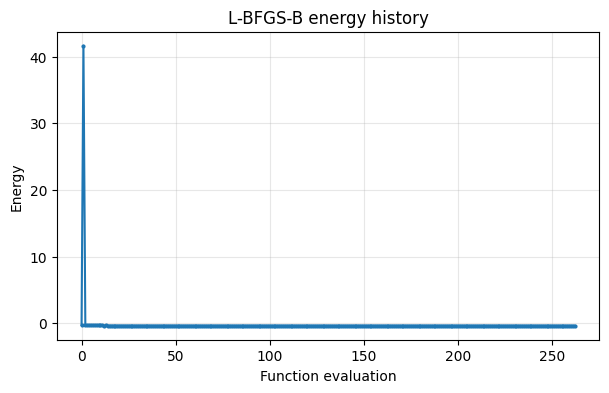

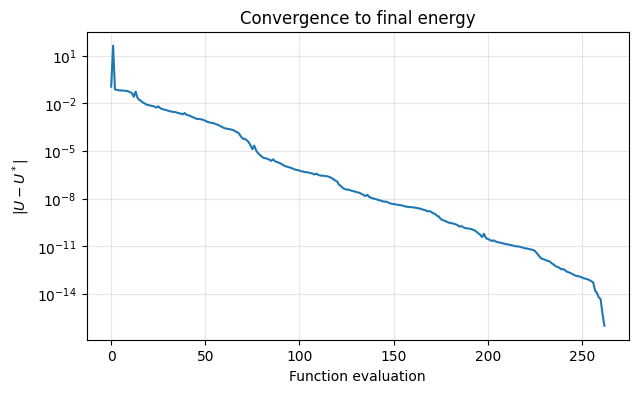

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(loss_hist, marker='o', ms=2)
plt.xlabel("Function evaluation")
plt.ylabel("Energy")
plt.title("L-BFGS-B energy history")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(np.abs(loss_hist - loss_hist[-1]) + 1e-16)
plt.xlabel("Function evaluation")
plt.ylabel(r"$|U - U^*|$")
plt.title("Convergence to final energy")
plt.grid(True, alpha=0.3)
plt.show()

## Exact solution

For this specific example, the governing ODE is simple enough that we can derive the exact
solution analytically. This gives a direct reference against which we can compare the
minimized field.

## Exact solution (derivation)

We consider the differential equation

$$
D \frac{d^2 \phi}{dx^2} + e^{-x} = 0.
$$

Rewriting,

$$
\frac{d^2 \phi}{dx^2} = -\frac{e^{-x}}{D}.
$$

### First integration

Integrate once with respect to $x$:

$$
\frac{d\phi}{dx} = \int -\frac{e^{-x}}{D} \, dx = \frac{e^{-x}}{D} + C_1.
$$

### Second integration

Integrate again:

$$
\phi(x) = \int \left( \frac{e^{-x}}{D} + C_1 \right) dx
= -\frac{e^{-x}}{D} + C_1 x + C_2.
$$

### Apply boundary conditions

We are given:

$$
\phi(0) = 1, \qquad \phi(1) = 0.1.
$$

At $x=0$:

$$
-\frac{1}{D} + C_2 = 1
\quad \Rightarrow \quad
C_2 = 1 + \frac{1}{D}.
$$

At $x=1$:

$$
-\frac{e^{-1}}{D} + C_1 + C_2 = 0.1.
$$

Substituting $C_2$:

$$
-\frac{e^{-1}}{D} + C_1 + \left(1 + \frac{1}{D}\right) = 0.1,
$$

which gives

$$
C_1 = 0.1 - 1 - \frac{1}{D} + \frac{e^{-1}}{D}.
$$

### Final exact solution

$$
\phi(x) = -\frac{e^{-x}}{D} + C_1 x + C_2.
$$

This analytical solution will be used as a reference to validate the numerical implementation.

In [ ]:
def phi_exact(x):
    C2 = 1.0 + 1.0 / D
    C1 = 0.1 - C2 + jnp.exp(-1.0) / D
    return -(1.0 / D) * jnp.exp(-x) + C1 * x + C2

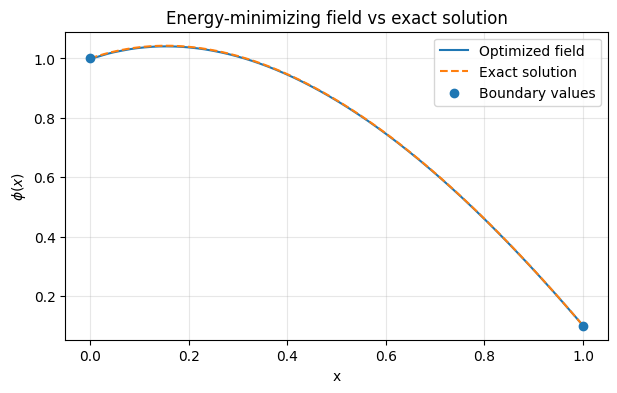

In [ ]:
phi_opt = phi_hat(x_plot, theta_opt)
phi_ref = phi_exact(x_plot)

plt.figure(figsize=(7,4))
plt.plot(x_plot, phi_opt, label="Optimized field")
plt.plot(x_plot, phi_ref, "--", label="Exact solution")
plt.scatter([0.0, 1.0], [phi_left, phi_right], zorder=3, label="Boundary values")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Energy-minimizing field vs exact solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
max_err = jnp.max(jnp.abs(phi_opt - phi_ref))
print("Max abs error =", float(max_err))

Max abs error = 0.0028848609970077987


## Residual check of the optimized field

Matching the exact solution visually is useful, but it is also important to verify that
the optimized field approximately satisfies the governing ODE.

The steady-state equation is

$$
-D \phi''(x) = q(x),
$$

so the residual is

$$
r(x) = -D \phi''(x) - q(x).
$$

If the implementation is correct and the optimizer has found a good minimum, then the
residual should be small across the domain.

Residual L2 norm  = 0.797664496143937
Residual max norm = 5.057000164454146


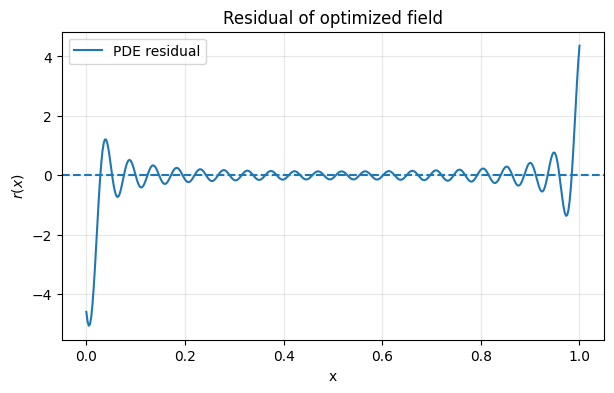

In [ ]:
def d2phi_dx2(x, theta):
    """
    Computes d^2(phi)/dx^2 using JAX automatic differentiation.
    """
    def phi_single(x_scalar):
        return phi_hat(jnp.array([x_scalar]), theta)[0]

    return jax.vmap(jax.grad(jax.grad(phi_single)))(x)

def pde_residual(x, theta):
    return -D * d2phi_dx2(x, theta) - q_source(x)

res_opt = pde_residual(x_plot, theta_opt)

print("Residual L2 norm  =", float(jnp.sqrt(jnp.mean(res_opt**2))))
print("Residual max norm =", float(jnp.max(jnp.abs(res_opt))))


plt.figure(figsize=(7,4))
plt.plot(x_plot, res_opt, label="PDE residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel(r"$r(x)$")
plt.title("Residual of optimized field")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## SGLD sampling from the physics-informed density

Since the deterministic optimization has already produced a stable low-energy solution,
we now move to sampling.

We define the physics-informed density as

$$
p(\theta \mid \beta) \propto \exp(-\beta U(\theta)),
$$

where:
- $U(\theta)$ is the energy functional,
- $\beta > 0$ controls how strongly the distribution concentrates around low-energy solutions.

To generate samples from this density, we use stochastic gradient Langevin dynamics (SGLD):

$$
\theta_{k+1}
=
\theta_k
-
\eta \, \beta \nabla_\theta U(\theta_k)
+
\sqrt{2\eta}\,\xi_k,
\qquad
\xi_k \sim \mathcal{N}(0, I).
$$

We initialize the chain near the deterministic optimizer so that sampling starts in a
physically meaningful region of parameter space.

In [ ]:
def neg_log_target(theta, beta):
    return beta * energy_U(theta)

neg_log_target_grad = jax.jit(jax.grad(neg_log_target, argnums=0))

## SGLD sampler implementation

The following function runs a basic fixed-step SGLD chain with:
- burn-in,
- thinning,
- retained samples,
- energy trace for diagnostics.

In [ ]:
def sgld_sampler(theta_init, beta, step_size=1e-6, n_burn=3000, n_samples=1000, thin=10, seed=0):
    key = jax.random.PRNGKey(seed)
    theta = theta_init.copy()

    samples = []
    energy_trace = []

    total_steps = n_burn + n_samples * thin

    for k in range(total_steps):
        key, subkey = jax.random.split(key)
        noise = jax.random.normal(subkey, shape=theta.shape)

        grad = neg_log_target_grad(theta, beta)
        theta = theta - step_size * grad + jnp.sqrt(2.0 * step_size) * noise

        if k >= n_burn and (k - n_burn) % thin == 0:
            samples.append(theta)
            energy_trace.append(energy_U(theta))

    return jnp.stack(samples), jnp.array(energy_trace)

## Run one SGLD chain

We first test the sampler for one representative value of $\beta$.
This helps verify that the chain is numerically stable before sweeping over multiple values.

In [ ]:
beta = 20.0

key = jax.random.PRNGKey(123)
theta_init_sgld = theta_opt + 0.01 * jax.random.normal(key, shape=theta_opt.shape)

samples, energy_trace = sgld_sampler(
    theta_init=theta_init_sgld,
    beta=beta,
    step_size=1e-6,
    n_burn=3000,
    n_samples=800,
    thin=20,
    seed=1,
)

print("samples shape:", samples.shape)
print("mean sampled energy:", float(jnp.mean(energy_trace)))
print("std sampled energy :", float(jnp.std(energy_trace)))

samples shape: (800, 41)
mean sampled energy: 0.5036380292559653
std sampled energy : 0.18738682233919396


## Energy trace of the retained SGLD samples

A stable sampler should produce an energy trace that fluctuates around a reasonable range
without diverging.

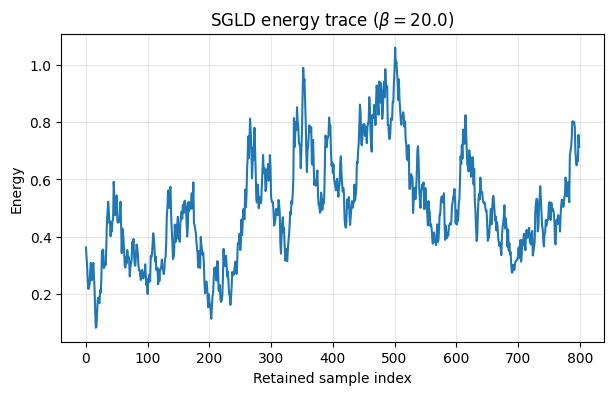

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(energy_trace)
plt.xlabel("Retained sample index")
plt.ylabel("Energy")
plt.title(fr"SGLD energy trace ($\beta={beta}$)")
plt.grid(True, alpha=0.3)
plt.show()

## Convert sampled coefficients into sampled fields

Each sampled parameter vector defines a field $\hat{\phi}(x;\theta)$.
From these field samples, we compute the sample mean and a 90% pointwise uncertainty band.

In [ ]:
phi_samples = jax.vmap(lambda th: phi_hat(x_plot, th))(samples)

phi_mean = jnp.mean(phi_samples, axis=0)
phi_p05 = jnp.percentile(phi_samples, 5.0, axis=0)
phi_p95 = jnp.percentile(phi_samples, 95.0, axis=0)

print("phi_samples shape:", phi_samples.shape)

phi_samples shape: (800, 400)


## Sampled fields and uncertainty band

This plot shows:
- a subset of sampled fields,
- the sample mean,
- the 90% pointwise band,
- the exact reference solution.

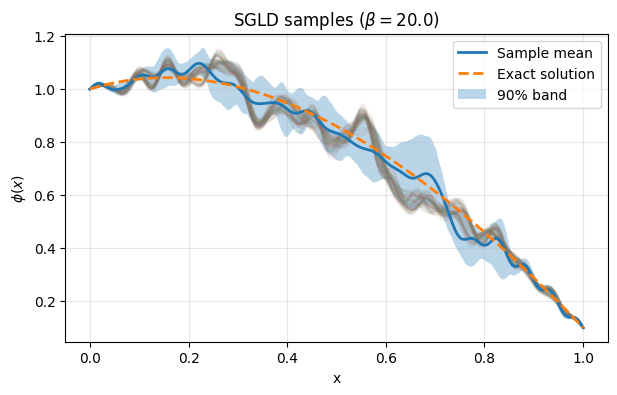

In [ ]:
plt.figure(figsize=(7,4))

n_show = min(100, phi_samples.shape[0])
for i in range(n_show):
    plt.plot(x_plot, phi_samples[i], alpha=0.06)

plt.plot(x_plot, phi_mean, linewidth=2, label="Sample mean")
plt.plot(x_plot, phi_ref, "--", linewidth=2, label="Exact solution")
plt.fill_between(x_plot, phi_p05, phi_p95, alpha=0.3, label="90% band")

plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title(fr"SGLD samples ($\beta={beta}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Sweep over multiple values of $\beta$

We now repeat the SGLD procedure for several inverse-temperature values in order to study
how the distribution sharpens as $\beta$ increases.

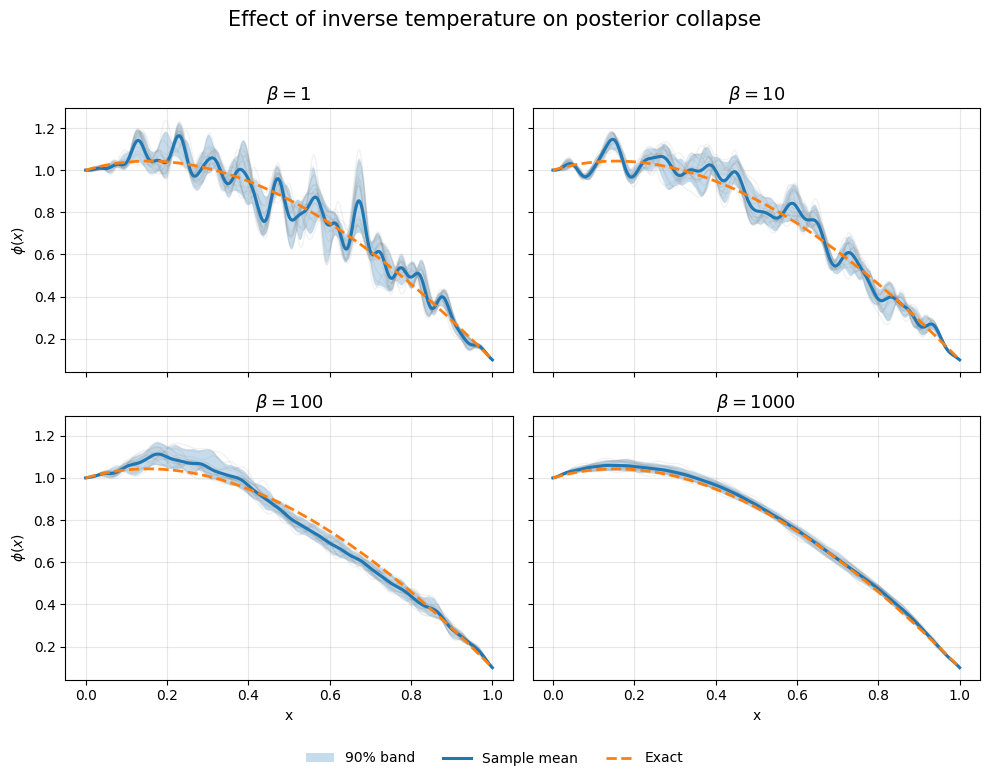

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

beta_list = [1, 10, 100, 1000]
beta_results = {}

for beta in beta_list:
    samples_beta, energy_trace_beta = sgld_sampler(
        theta_init=theta_init_sgld,
        beta=beta,
        step_size=1e-6,
        n_burn=3000,
        n_samples=600,
        thin=20,
        seed=int(beta * 10) + 1,
    )

    phi_samples_beta = jax.vmap(lambda th: phi_hat(x_plot, th))(samples_beta)

    beta_results[beta] = {
        "phi_samples": np.array(phi_samples_beta),
        "phi_mean": np.array(jnp.mean(phi_samples_beta, axis=0)),
        "phi_p05": np.array(jnp.percentile(phi_samples_beta, 5.0, axis=0)),
        "phi_p95": np.array(jnp.percentile(phi_samples_beta, 95.0, axis=0)),
    }

# ---------- 2x2 publication-style figure ----------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, beta in zip(axes, beta_list):
    res = beta_results[beta]
    phi_samples = res["phi_samples"]

    # show a few raw posterior samples in the background
    n_show = min(20, phi_samples.shape[0])
    idx = np.linspace(0, phi_samples.shape[0] - 1, n_show, dtype=int)
    for i in idx:
        ax.plot(x_plot, phi_samples[i], color="gray", alpha=0.10, linewidth=1.0)

    # uncertainty band
    ax.fill_between(
        x_plot,
        res["phi_p05"],
        res["phi_p95"],
        alpha=0.25,
        label="90% band"
    )

    # sample mean and exact
    ax.plot(x_plot, res["phi_mean"], linewidth=2.2, label="Sample mean")
    ax.plot(x_plot, phi_ref, "--", linewidth=2.0, label="Exact")

    ax.set_title(fr"$\beta = {beta}$", fontsize=13)
    ax.grid(True, alpha=0.3)

# axis labels only on outer panels
axes[0].set_ylabel(r"$\phi(x)$")
axes[2].set_ylabel(r"$\phi(x)$")
axes[2].set_xlabel("x")
axes[3].set_xlabel("x")

# one legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))

fig.suptitle("Effect of inverse temperature on posterior collapse", fontsize=15)
fig.tight_layout(rect=[0, 0.07, 1, 0.95])

# save in professional formats
fig.savefig("pift_beta_sweep_checkpoint.png", dpi=300, bbox_inches="tight")
fig.savefig("pift_beta_sweep_checkpoint.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# Save as SVG for LaTeX
fig.savefig("pift_beta_sweep_checkpoint.svg", format="svg", bbox_inches="tight")

# PIFT Example 5.2 in JAX (Inverse Problem)

## Synthetic data for the inverse problem

To estimate the inverse temperature parameter $\beta$, observations of the field are needed.
Following the spirit of Example 5.2 in the paper, synthetic measurements are generated from the known analytical solution with additive Gaussian noise.

These observations define the likelihood term, while $\beta$ controls the strength of the
physics-informed prior.

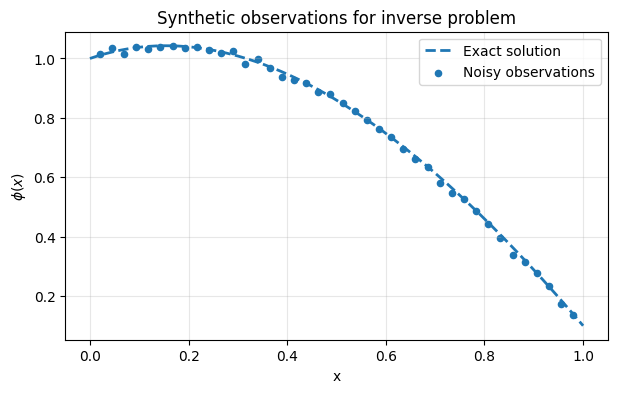

In [ ]:
# ------------------------------------------------------------
# Synthetic observations from the exact solution
# ------------------------------------------------------------
key = jax.random.PRNGKey(2025)

n_obs = 40
x_obs = jnp.linspace(0.02, 0.98, n_obs)   # avoid exact boundaries
sigma_obs = 0.01

phi_obs_true = phi_exact(x_obs)
key, subkey = jax.random.split(key)
y_obs = phi_obs_true + sigma_obs * jax.random.normal(subkey, shape=x_obs.shape)

plt.figure(figsize=(7,4))
plt.plot(x_plot, phi_ref, "--", linewidth=2, label="Exact solution")
plt.scatter(x_obs, y_obs, s=20, label="Noisy observations")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Synthetic observations for inverse problem")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Likelihood model

The observation model assumes independent Gaussian noise:

$$
y_i = \phi(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\sigma^2).
$$

This gives the negative log-likelihood, up to an additive constant,

$$
\Phi(d,\theta)
=
\frac{1}{2\sigma^2}\sum_{i=1}^N \left(\phi(x_i;\theta)-y_i\right)^2.
$$

The posterior over field parameters for a fixed $\beta$ is then proportional to

$$
p(\theta \mid d,\beta) \propto \exp\left[-\Phi(d,\theta)-\beta U(\theta)\right].
$$

In [ ]:
def neg_log_likelihood(theta, x_obs, y_obs, sigma_obs):
    pred = phi_hat(x_obs, theta)
    return 0.5 * jnp.sum(((pred - y_obs) / sigma_obs) ** 2)

def total_neg_log_posterior(theta, beta, x_obs, y_obs, sigma_obs):
    return neg_log_likelihood(theta, x_obs, y_obs, sigma_obs) + beta * energy_U(theta)

## SGLD sampler for the field posterior at fixed $\beta$

For inverse estimation of $\beta$, two field samplers are needed:

1. a sampler from the prior:
   $$
   p(\theta \mid \beta) \propto \exp(-\beta U(\theta)),
   $$
2. a sampler from the posterior:
   $$
   p(\theta \mid d,\beta) \propto \exp(-\Phi(d,\theta)-\beta U(\theta)).
   $$

The current notebook already contains the prior sampler. The function below adds the
posterior sampler for fixed $\beta$.

In [ ]:
def sgld_posterior_sampler(
    theta_init,
    beta,
    x_obs,
    y_obs,
    sigma_obs,
    step_size=1e-6,
    n_burn=3000,
    n_samples=400,
    thin=20,
    seed=0,
):
    key = jax.random.PRNGKey(seed)
    theta = theta_init.copy()

    samples = []
    trace = []

    grad_fn = jax.jit(jax.grad(total_neg_log_posterior, argnums=0))

    total_steps = n_burn + n_samples * thin

    for k in range(total_steps):
        key, subkey = jax.random.split(key)
        noise = jax.random.normal(subkey, shape=theta.shape)

        grad = grad_fn(theta, beta, x_obs, y_obs, sigma_obs)
        theta = theta - step_size * grad + jnp.sqrt(2.0 * step_size) * noise

        if k >= n_burn and (k - n_burn) % thin == 0:
            samples.append(theta)
            trace.append(total_neg_log_posterior(theta, beta, x_obs, y_obs, sigma_obs))

    return jnp.stack(samples), jnp.array(trace)

## Parameterization of the inverse temperature

Since $\beta$ must remain positive, it is more convenient to work in log-space:

$$
\lambda = \log \beta, \qquad \beta = e^\lambda.
$$

The inverse problem is therefore posed as inference over $\lambda$ rather than directly over $\beta$.

In [ ]:
def lambda_to_beta(lam):
    return jnp.exp(lam)

## Approximate gradient for the outer inverse update

Inspired by the inverse formulation in the paper, the update for $\lambda=\log\beta$
is built from a difference of expectations between:

- the posterior field distribution conditional on data and $\beta$,
- the prior field distribution conditional on $\beta$.

For this simplified implementation, the outer gradient is approximated as

$$
g_\lambda
\approx
\beta \,\mathbb{E}_{post}[U(\theta)]
-
\beta \,\mathbb{E}_{prior}[U(\theta)].
$$

A flat prior over $\lambda$ is used for now, so no additional prior-gradient term is added.

In [ ]:
def estimate_lambda_gradient(prior_samples, post_samples, beta):
    U_prior = jax.vmap(energy_U)(prior_samples)
    U_post  = jax.vmap(energy_U)(post_samples)

    grad_est = beta * (jnp.mean(U_post) - jnp.mean(U_prior))

    stats = {
        "U_prior_mean": jnp.mean(U_prior),
        "U_post_mean": jnp.mean(U_post),
        "U_prior_std": jnp.std(U_prior),
        "U_post_std": jnp.std(U_post),
    }
    return grad_est, stats

## Nested inverse loop for estimating $\beta$

The inverse estimation proceeds in two levels:

1. Fix the current $\beta$ and sample the field from the prior.
2. Fix the same $\beta$ and sample the field from the posterior.
3. Use the difference in expected energies to update $\lambda=\log\beta$.

This is a simplified nested SGLD implementation inspired by the paper's inverse methodology.

In [ ]:
def estimate_beta_nested(
    lambda_init,
    theta_init_prior,
    theta_init_post,
    x_obs,
    y_obs,
    sigma_obs,
    outer_steps=30,
    outer_step_size=1e-2,
    prior_step_size=1e-6,
    post_step_size=1e-6,
    n_burn_inner=1500,
    n_samples_inner=200,
    thin_inner=10,
    seed=0,
):
    key = jax.random.PRNGKey(seed)

    lam = jnp.array(lambda_init)
    lambda_trace = []
    beta_trace = []
    grad_trace = []
    prior_energy_trace = []
    post_energy_trace = []

    theta_prior_ref = theta_init_prior.copy()
    theta_post_ref = theta_init_post.copy()

    for t in range(outer_steps):
        beta = lambda_to_beta(lam)

        # Prior samples p(theta | beta)
        prior_samples, _ = sgld_sampler(
            theta_init=theta_prior_ref,
            beta=beta,
            step_size=prior_step_size,
            n_burn=n_burn_inner,
            n_samples=n_samples_inner,
            thin=thin_inner,
            seed=1000 + t,
        )

        # Posterior samples p(theta | d, beta)
        post_samples, _ = sgld_posterior_sampler(
            theta_init=theta_post_ref,
            beta=beta,
            x_obs=x_obs,
            y_obs=y_obs,
            sigma_obs=sigma_obs,
            step_size=post_step_size,
            n_burn=n_burn_inner,
            n_samples=n_samples_inner,
            thin=thin_inner,
            seed=2000 + t,
        )

        # Warm-start next outer iteration from final retained samples
        theta_prior_ref = prior_samples[-1]
        theta_post_ref = post_samples[-1]

        # Estimate outer gradient
        grad_lam, stats = estimate_lambda_gradient(prior_samples, post_samples, beta)

        # Simple Langevin/gradient-style outer update on lambda
        key, subkey = jax.random.split(key)
        noise = 0.05 * jax.random.normal(subkey, shape=())
        lam = lam - outer_step_size * grad_lam + jnp.sqrt(2.0 * outer_step_size) * noise

        # store
        lambda_trace.append(lam)
        beta_trace.append(beta)
        grad_trace.append(grad_lam)
        prior_energy_trace.append(stats["U_prior_mean"])
        post_energy_trace.append(stats["U_post_mean"])

        print(
            f"outer {t:02d} | beta={float(beta):10.4f} | "
            f"grad_lambda={float(grad_lam): .4e} | "
            f"E_post[U]={float(stats['U_post_mean']): .4e} | "
            f"E_prior[U]={float(stats['U_prior_mean']): .4e}"
        )

    return {
        "lambda_trace": jnp.array(lambda_trace),
        "beta_trace": jnp.array(beta_trace),
        "grad_trace": jnp.array(grad_trace),
        "prior_energy_trace": jnp.array(prior_energy_trace),
        "post_energy_trace": jnp.array(post_energy_trace),
        "theta_prior_last": theta_prior_ref,
        "theta_post_last": theta_post_ref,
    }

## Run inverse estimation of $\beta$

The inverse loop is initialized from a moderate value of $\beta$ in log-space.
The result is not expected to exactly reproduce the paper's Example 2, since this notebook
uses a simplified implementation and a different forward problem. However, it should show
whether the estimated $\beta$ moves toward values that balance the data and physics.

In [ ]:
# initialize from deterministic optimizer + small perturbation
key = jax.random.PRNGKey(99)
theta_init_prior = theta_opt + 0.01 * jax.random.normal(key, shape=theta_opt.shape)

key, subkey = jax.random.split(key)
theta_init_post = theta_opt + 0.01 * jax.random.normal(subkey, shape=theta_opt.shape)

lambda_init = jnp.log(10.0)   # initial beta = 10

inv_results = estimate_beta_nested(
    lambda_init=lambda_init,
    theta_init_prior=theta_init_prior,
    theta_init_post=theta_init_post,
    x_obs=x_obs,
    y_obs=y_obs,
    sigma_obs=sigma_obs,
    outer_steps=25,
    outer_step_size=5e-3,
    prior_step_size=1e-6,
    post_step_size=1e-6,
    n_burn_inner=1000,
    n_samples_inner=150,
    thin_inner=10,
    seed=123,
)

outer 00 | beta=   10.0000 | grad_lambda=-7.9791e+00 | E_post[U]=-1.5880e-01 | E_prior[U]= 6.3910e-01
outer 01 | beta=   10.3714 | grad_lambda=-1.0460e+01 | E_post[U]=-2.4187e-01 | E_prior[U]= 7.6671e-01
outer 02 | beta=   10.9545 | grad_lambda=-1.1570e+01 | E_post[U]=-2.2330e-01 | E_prior[U]= 8.3290e-01
outer 03 | beta=   11.5379 | grad_lambda=-1.0017e+01 | E_post[U]=-2.2918e-01 | E_prior[U]= 6.3897e-01
outer 04 | beta=   12.0407 | grad_lambda=-1.1804e+01 | E_post[U]=-2.5392e-01 | E_prior[U]= 7.2643e-01
outer 05 | beta=   12.5920 | grad_lambda=-1.1838e+01 | E_post[U]=-2.3696e-01 | E_prior[U]= 7.0313e-01
outer 06 | beta=   13.3491 | grad_lambda=-1.5570e+01 | E_post[U]=-2.2240e-01 | E_prior[U]= 9.4393e-01
outer 07 | beta=   14.4646 | grad_lambda=-1.4406e+01 | E_post[U]=-2.6008e-01 | E_prior[U]= 7.3588e-01
outer 08 | beta=   15.5080 | grad_lambda=-1.7034e+01 | E_post[U]=-2.2381e-01 | E_prior[U]= 8.7461e-01
outer 09 | beta=   16.9647 | grad_lambda=-1.4939e+01 | E_post[U]=-2.2715e-01 | E_p

## Trace of the estimated inverse temperature

The plot below shows how the inferred $\beta$ evolves during the outer iterations.
This provides a first diagnostic for whether the inverse loop is stable and whether
the data favor stronger or weaker trust in the physics.

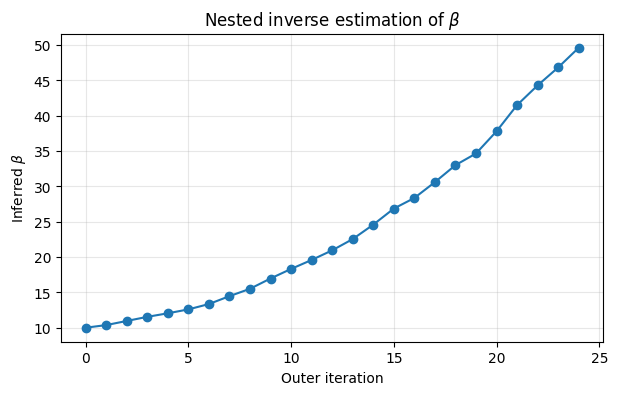

Final estimated beta = 49.629696797572855


In [ ]:
plt.figure(figsize=(7,4))
plt.plot(inv_results["beta_trace"], marker="o")
plt.xlabel("Outer iteration")
plt.ylabel(r"Inferred $\beta$")
plt.title(r"Nested inverse estimation of $\beta$")
plt.grid(True, alpha=0.3)
plt.show()

print("Final estimated beta =", float(inv_results["beta_trace"][-1]))

## Prior vs posterior expected energies

The outer inverse update is driven by the difference between the posterior and prior
expected energies. Tracking both quantities helps interpret the direction of the $\beta$
updates.

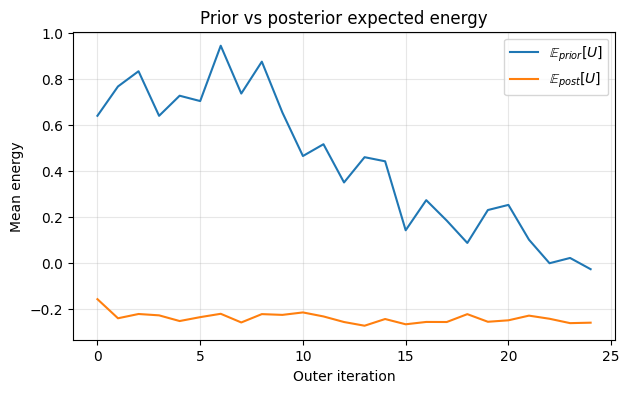

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(inv_results["prior_energy_trace"], label=r"$\mathbb{E}_{prior}[U]$")
plt.plot(inv_results["post_energy_trace"], label=r"$\mathbb{E}_{post}[U]$")
plt.xlabel("Outer iteration")
plt.ylabel("Mean energy")
plt.title("Prior vs posterior expected energy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Posterior field using the inferred $\beta$

After the inverse loop converges to a reasonable value of $\beta$, the posterior field
can be sampled again using this final estimate.

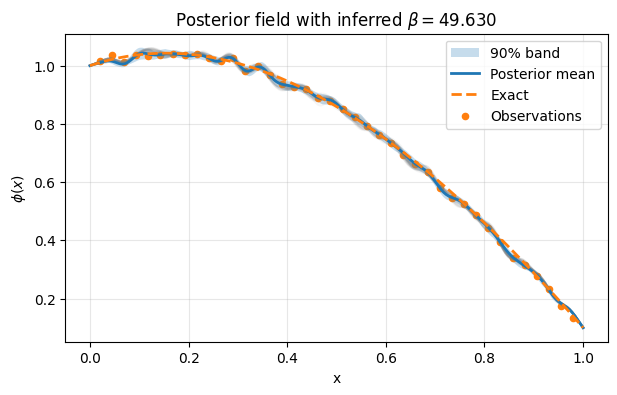

In [ ]:
beta_est = float(inv_results["beta_trace"][-1])

samples_final, trace_final = sgld_posterior_sampler(
    theta_init=inv_results["theta_post_last"],
    beta=beta_est,
    x_obs=x_obs,
    y_obs=y_obs,
    sigma_obs=sigma_obs,
    step_size=1e-6,
    n_burn=2000,
    n_samples=400,
    thin=10,
    seed=777,
)

phi_samples_final = jax.vmap(lambda th: phi_hat(x_plot, th))(samples_final)
phi_mean_final = jnp.mean(phi_samples_final, axis=0)
phi_p05_final = jnp.percentile(phi_samples_final, 5.0, axis=0)
phi_p95_final = jnp.percentile(phi_samples_final, 95.0, axis=0)

plt.figure(figsize=(7,4))

n_show = min(25, phi_samples_final.shape[0])
for i in range(n_show):
    plt.plot(x_plot, phi_samples_final[i], color="gray", alpha=0.08)

plt.fill_between(x_plot, phi_p05_final, phi_p95_final, alpha=0.25, label="90% band")
plt.plot(x_plot, phi_mean_final, linewidth=2, label="Posterior mean")
plt.plot(x_plot, phi_ref, "--", linewidth=2, label="Exact")
plt.scatter(x_obs, y_obs, s=20, label="Observations")

plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title(fr"Posterior field with inferred $\beta = {beta_est:.3f}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("inverse.svg", format="svg", bbox_inches="tight")
plt.show()